In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from config.setting import NUM_COLUMNS
from utils.helper import get_data_path
import math

# configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
# sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

TARGET_COL = "price"  # target column name

df = pd.read_csv(get_data_path("final_data.csv"))

In [29]:
print(df.columns)

Index(['address', 'area', 'house_direction', 'balcony_direction', 'floors',
       'bedrooms', 'bathrooms', 'legal_status', 'furniture_state', 'price',
       'year', 'property_type', 'property_feature', 'lat', 'lng'],
      dtype='str')


In [3]:
print(df.shape)

(842922, 20)


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 842922 entries, 0 to 842921
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   name                842922 non-null  str    
 1   description         842922 non-null  str    
 2   property_type_name  842922 non-null  str    
 3   province_name       842922 non-null  str    
 4   district_name       827856 non-null  str    
 5   ward_name           762736 non-null  str    
 6   street_name         642465 non-null  str    
 7   project_name        7684 non-null    str    
 8   price               798085 non-null  float64
 9   area                842922 non-null  float64
 10  floor_count         343819 non-null  float64
 11  frontage_width      507051 non-null  float64
 12  house_depth         7916 non-null    float64
 13  road_width          193563 non-null  float64
 14  bedroom_count       563825 non-null  float64
 15  bathroom_count      523761 non-null  float64


In [5]:
print(df.isna().sum())

name                       0
description                0
property_type_name         0
province_name              0
district_name          15066
ward_name              80186
street_name           200457
project_name          835238
price                  44837
area                       0
floor_count           499103
frontage_width        335871
house_depth           835006
road_width            649359
bedroom_count         279097
bathroom_count        319161
house_direction       710423
balcony_direction     775863
published_at               0
address                    0
dtype: int64


In [30]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 0


In [7]:
df = df.drop_duplicates()


In [35]:
top5 = df.nlargest(14, "price")[["address","price"]]
print(top5)
print(top5.index)

                                                 address   price
20129       Đường số 9, Phường Linh Xuân, TP Hồ Chí Minh 250.000
18459    Đường Tô Hiệu, Phường Phú Thạnh, TP Hồ Chí Minh  17.500
18513    Đường Huỳnh Tấn Phát, Xã Nhà Bè, TP Hồ Chí Minh  17.500
18648  Đường Phạm Hữu Lầu, Phường Tân Mỹ, TP Hồ Chí ...  17.500
18669       0927377454, Phường Nhiêu Lộc, TP Hồ Chí Minh  17.500
18741  6 đs 15 p.chánh hưng tp.hcm, Phường Chánh Hưng...  17.500
18835  Đường Phạm Hữu Lầu, Phường Tân Mỹ, TP Hồ Chí ...  17.500
18872  Đường Phạm Văn Đồng, Phường Hạnh Thông, TP Hồ...  17.500
18880  Đường Phan Văn Trị, Phường Hạnh Thông, TP Hồ ...  17.500
18943  Đường Lâm Văn Bền, Phường Tân Hưng, TP Hồ Chí ...  17.500
19000  Đường Trần Quang Quá, Phường Phú Thạnh, TP Hồ ...  17.500
19042  Đường Trần Văn Ðang, Phường Nhiêu Lộc, TP Hồ C...  17.500
19088  Đường 3 Tháng 2, Phường Diên Hồng, TP Hồ Chí Minh  17.500
19251  Đường Phạm Hữu Lầu, Phường Tân Mỹ, TP Hồ Chí ...  17.500
Index([20129, 18459, 1851

In [36]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23336\2754926100.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [37]:
print("Target column:", TARGET_COL)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)
print(df[num_cols].describe().T)

Target column: price
Numerical columns: ['area', 'floors', 'bedrooms', 'bathrooms', 'price', 'year', 'lat', 'lng']
Categorical columns: ['address', 'house_direction', 'balcony_direction', 'legal_status', 'furniture_state', 'property_type', 'property_feature']
              count     mean    std      min      25%      50%      75%  \
area      20343.000   64.252 50.242    5.000   43.000   58.000   76.400   
floors    16040.000    2.931  1.608    1.000    2.000    3.000    4.000   
bedrooms  19132.000    3.434  1.517    1.000    2.000    3.000    4.000   
bathrooms 16013.000    3.272  1.473    1.000    2.000    3.000    4.000   
price     20343.000    6.579  3.185    1.000    4.694    6.290    8.150   
year      20343.000 2025.093  0.996 2024.000 2024.000 2026.000 2026.000   
lat       20343.000   10.798  0.050   10.403   10.763   10.798   10.836   
lng       20343.000  106.672  0.054  106.379  106.630  106.667  106.704   

               max  
area      4202.300  
floors      60.000  
b

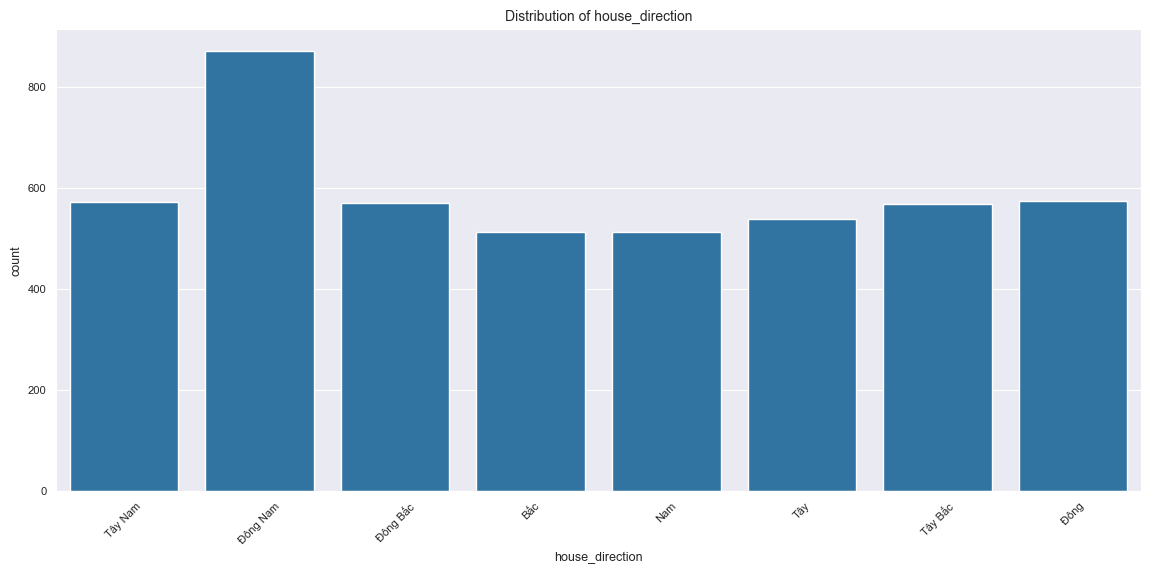

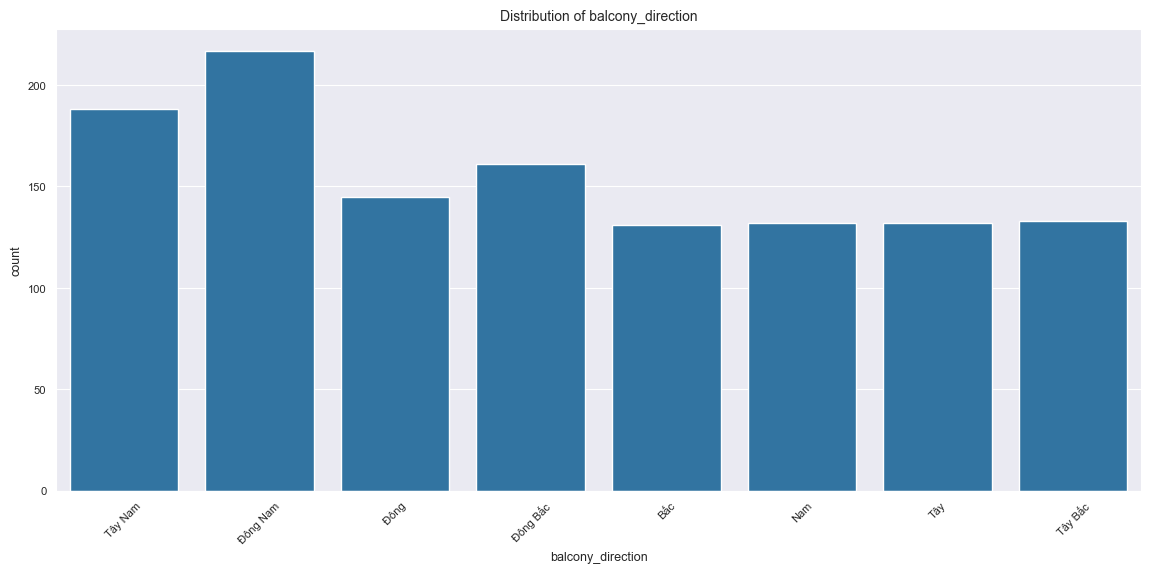

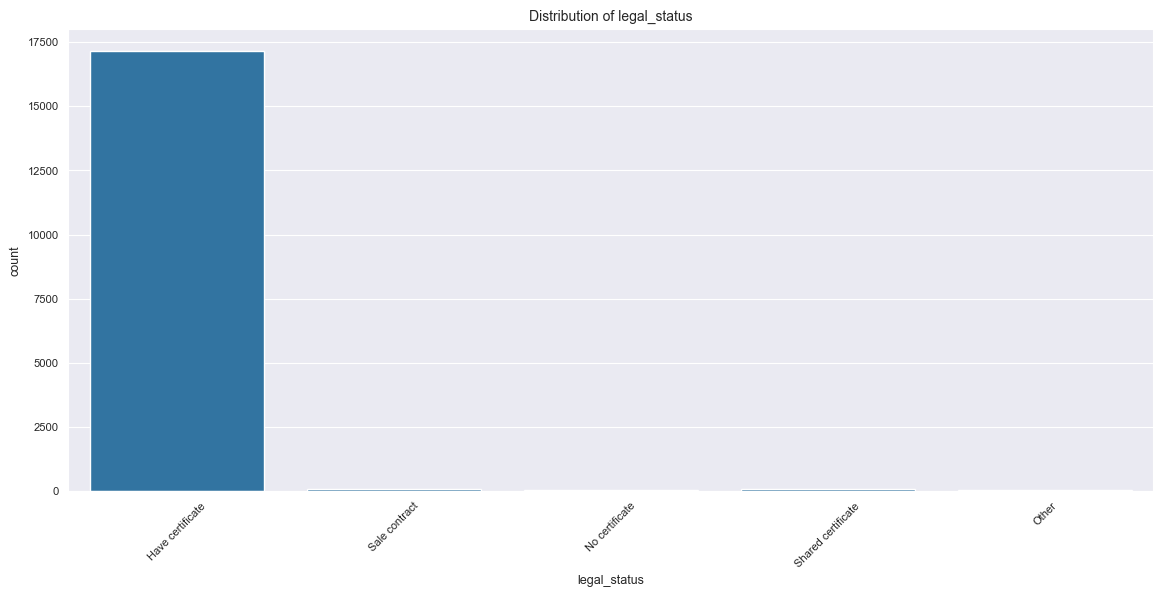

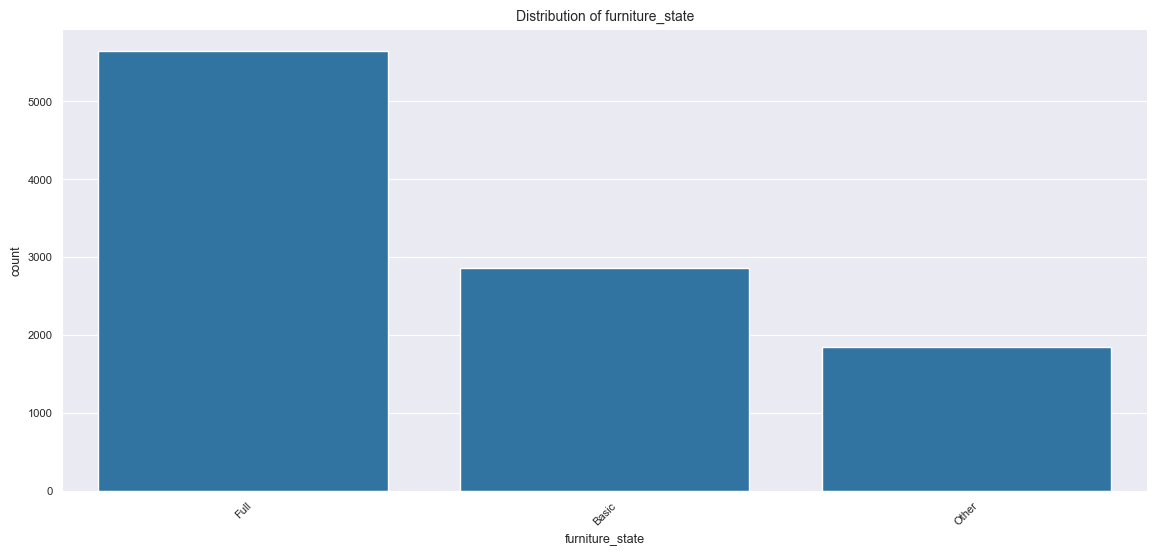

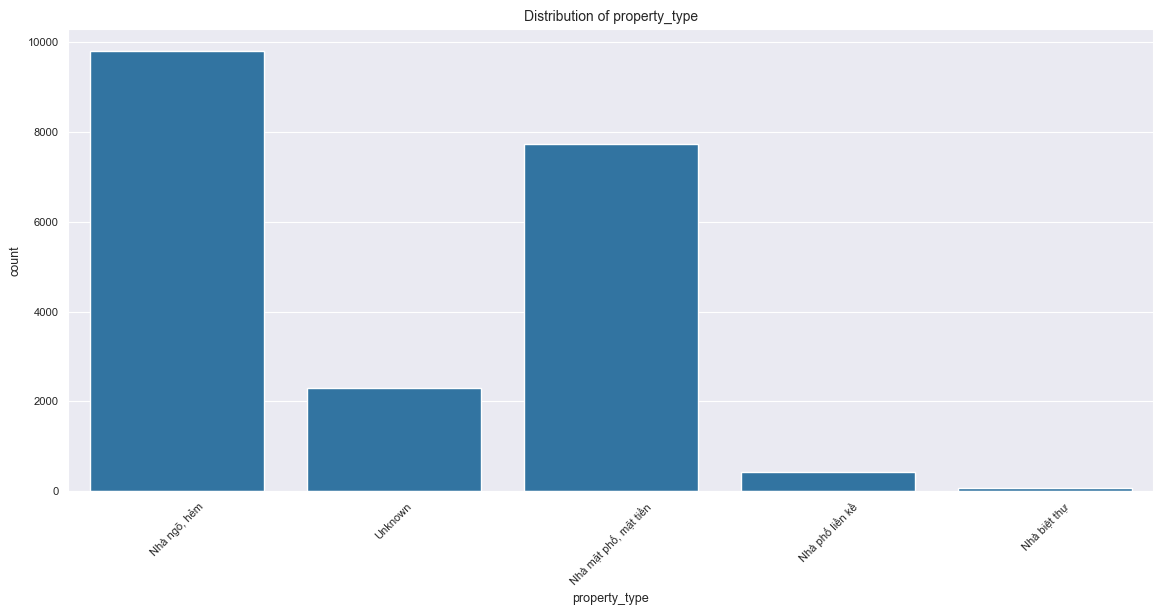

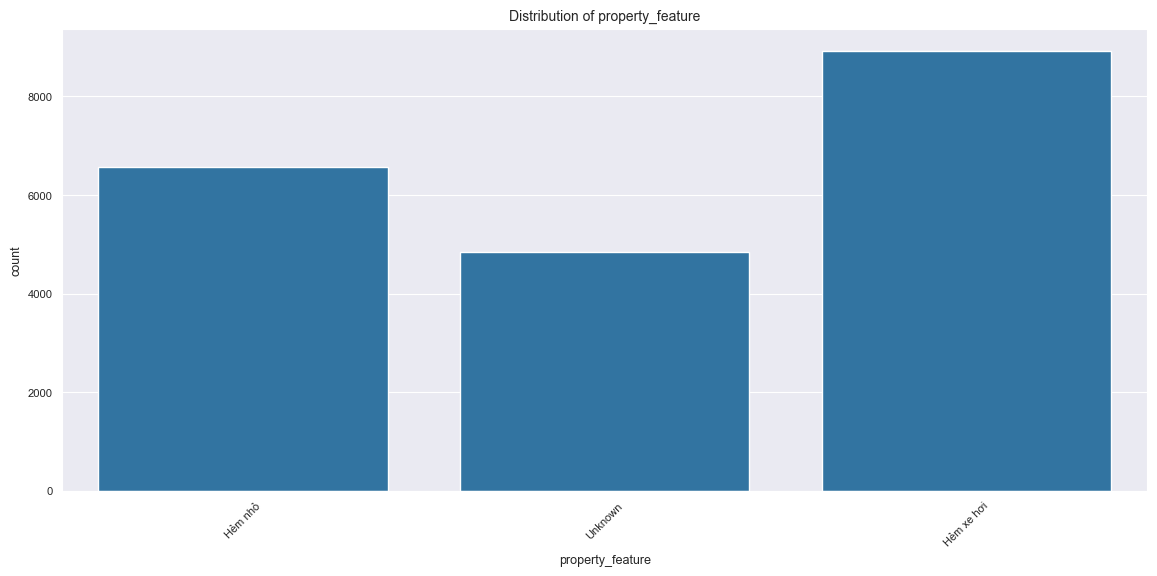

In [38]:
safe_cat_cols = [c for c in cat_cols if df[c].nunique() < 50]
for col in safe_cat_cols:
    plt.figure(figsize=(14, 6))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()


area
Top 5 max values:
12575   4202.300
15188   1568.000
9957    1300.000
19388    828.600
16577    628.000
Name: area, dtype: float64

floors
Top 5 max values:
12098   60.000
9928    50.000
17631   44.000
9590    44.000
9864    43.000
Name: floors, dtype: float64

bedrooms
Top 5 max values:
19309   11.000
14885   11.000
15053   11.000
19520   11.000
9408    11.000
Name: bedrooms, dtype: float64

bathrooms
Top 5 max values:
7485   9.000
6427   9.000
6112   9.000
6116   9.000
6035   9.000
Name: bathrooms, dtype: float64

price
Top 5 max values:
18970   13.750
18769   13.750
19533   13.700
19550   13.680
19150   13.600
Name: price, dtype: float64

year
Top 5 max values:
20355    2026
20352    2026
20351    2026
20349    2026
20348    2026
Name: year, dtype: int64

lat
Top 5 max values:
18997   11.388
13987   11.253
10056   11.183
13468   11.119
13600   11.105
Name: lat, dtype: float64

lng
Top 5 max values:
18236   107.040
19142   106.923
13097   106.923
9653    106.863
10692   106.861
N

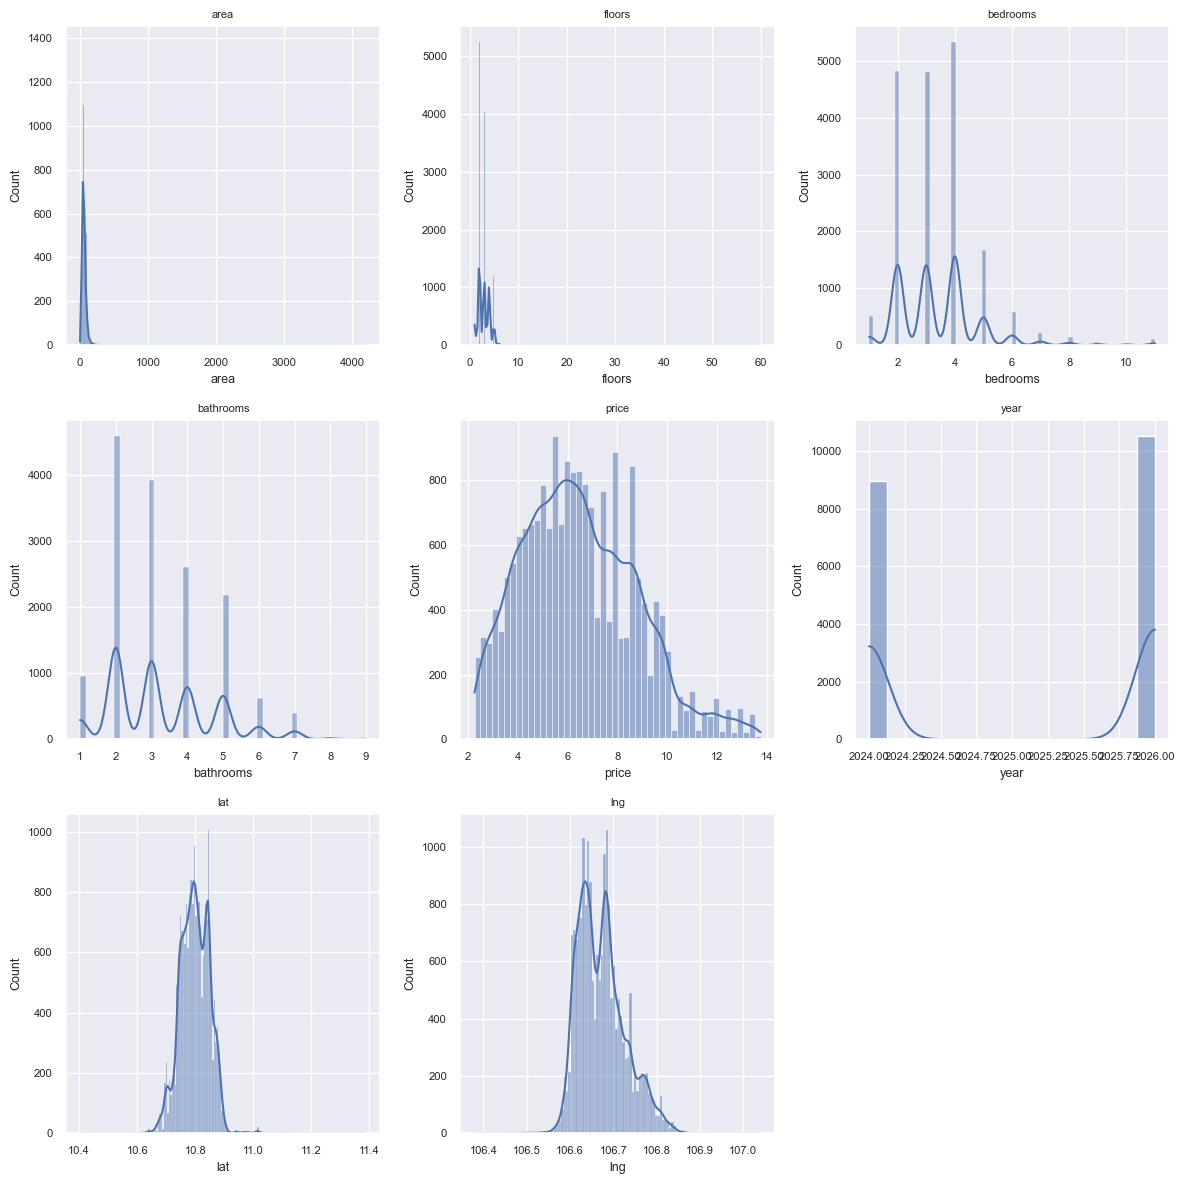

In [13]:

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)
for col in num_cols:
    print(col)
    print("Top 5 max values:")
    print(df[col].sort_values(ascending=False).head())
    print()
# Ẩn subplot dư
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



In [14]:
df["area"].sort_values(ascending=False).head()

13600   178.500
12001   178.000
7264    178.000
804     177.000
2576    177.000
Name: area, dtype: float64

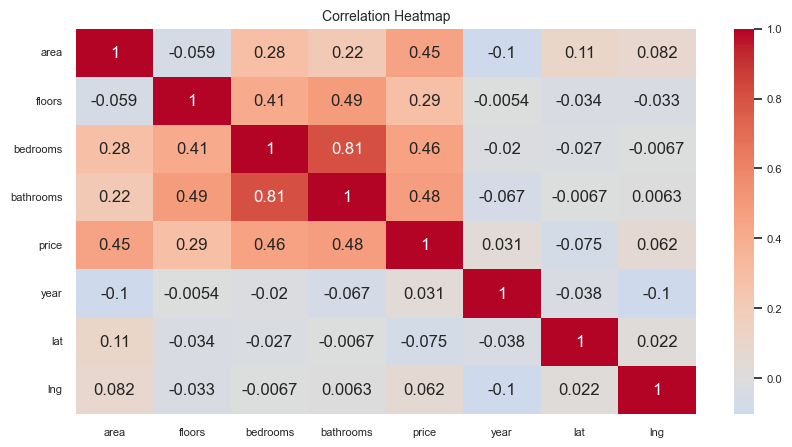


Correlation with target:
price        1.000
bathrooms    0.482
bedrooms     0.457
area         0.446
floors       0.285
lng          0.062
year         0.031
lat         -0.075
Name: price, dtype: float64


In [15]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

# Correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


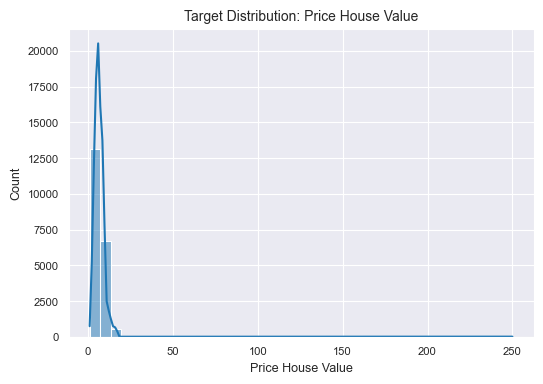

        price
20129 250.000
18459  17.500
18513  17.500
18648  17.500
18669  17.500


In [41]:
# target column distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['price'], bins=40, kde=True)
plt.title("Target Distribution: Price House Value")
plt.xlabel("Price House Value")
plt.show()
top5 = df.nlargest(5, "price")[["price"]]
print(top5)


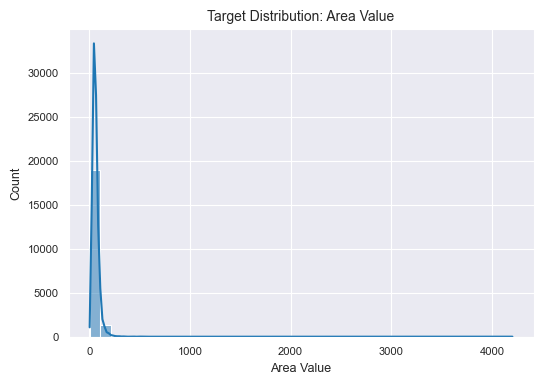

area
60.000     1073
40.000      749
80.000      664
50.000      647
56.000      543
           ... 
110.250       1
83.800        1
13.700        1
10.100        1
11.200        1
Name: count, Length: 1191, dtype: int64


In [42]:
plt.figure(figsize=(6, 4))
sns.histplot(df['area'], bins=40, kde=True)
plt.title("Target Distribution: Area Value")

plt.xlabel("Area Value")
plt.show()
print(df['area'].value_counts())


In [18]:
print("Floors > 15:", (df["floors"] > 15).sum())
print("Floors is NaN:", df["floors"].isna().sum())

Floors > 15: 18
Floors is NaN: 3984


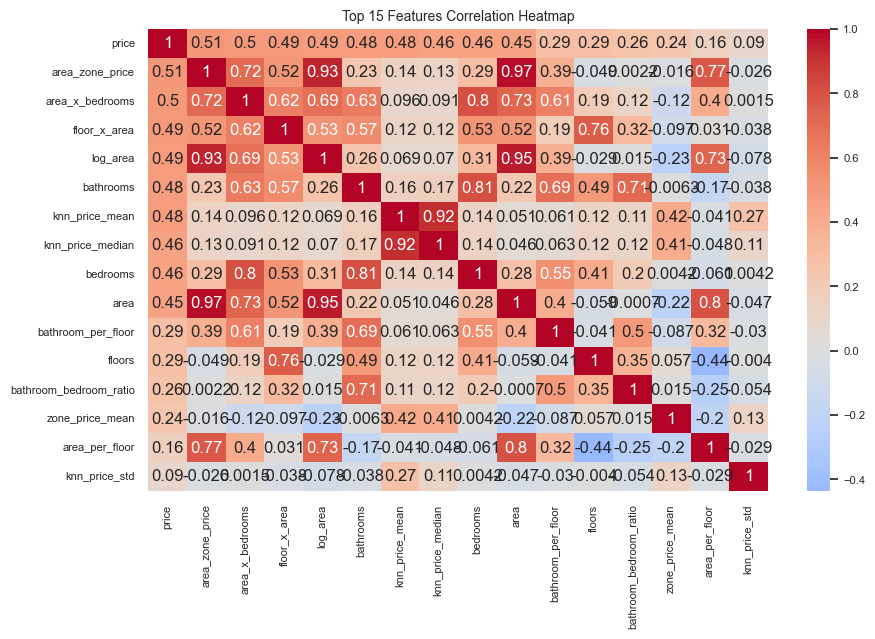


Top 15 features correlated with target:
price                    1.000
area_zone_price          0.508
area_x_bedrooms          0.499
floor_x_area             0.495
log_area                 0.485
bathrooms                0.482
knn_price_mean           0.480
knn_price_median         0.460
bedrooms                 0.457
area                     0.446
bathroom_per_floor       0.290
floors                   0.285
bathroom_bedroom_ratio   0.263
zone_price_mean          0.237
area_per_floor           0.158
knn_price_std            0.090


In [19]:
from features.feature_engineering import build_features

df = build_features(df, mode="train")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)

top15_features = corr_with_target.drop(TARGET_COL).head(15).index.tolist()

cols_for_heatmap = [TARGET_COL] + top15_features

# ===== Heatmap =====
plt.figure(figsize=(10, 6))
sns.heatmap(
    df[cols_for_heatmap].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Top 15 Features Correlation Heatmap")
plt.show()

# ===== In ra correlation =====
print("\nTop 15 features correlated with target:")
print(corr_with_target.head(16).to_string())  # 16 vì có cả target
